In [244]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor, XGBClassifier
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.under_sampling import RandomUnderSampler

In [245]:
df_bureau=pd.read_csv("C:\\Users\\vaisa\\Downloads\\project_2\\dataset\\bureau_data.csv")
df_customers=pd.read_csv("C:\\Users\\vaisa\\Downloads\\project_2\\dataset\\customers.csv")
df_loans=pd.read_csv("C:\\Users\\vaisa\\Downloads\\project_2\\dataset\\loans.csv")

In [246]:
df=pd.merge(df_bureau, df_customers, on='cust_id')
df=pd.merge(df, df_loans, on='cust_id')

In [247]:
df['zipcode'].values

array([110001, 600001, 700001, ..., 560001, 500001, 400001],
      shape=(50000,))

In [248]:
x=df.drop(columns='default')
y=df[['default']]


In [249]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [250]:
df_train=pd.concat([x_train, y_train], axis=1)
df_train['default']=df_train['default'].astype('int')
df_train["residence_type"]=df_train.residence_type.fillna('Owned')
df_train.isna().sum()


cust_id                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [251]:
df_test=pd.concat([x_test, y_test], axis=1)
df_test["residence_type"]=df_test.residence_type.fillna('Owned')

df_test.isna().sum()

cust_id                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [252]:

number_cols = ['number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months','bank_balance_at_application', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'age', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement','income', 'number_of_dependants', 'zipcode','years_at_current_address','loan_tenure_months']
continuous_cols = ['cust_id', 'gender', 'disbursal_date', 'processing_fee', 'gst', 'installment_start_dt']


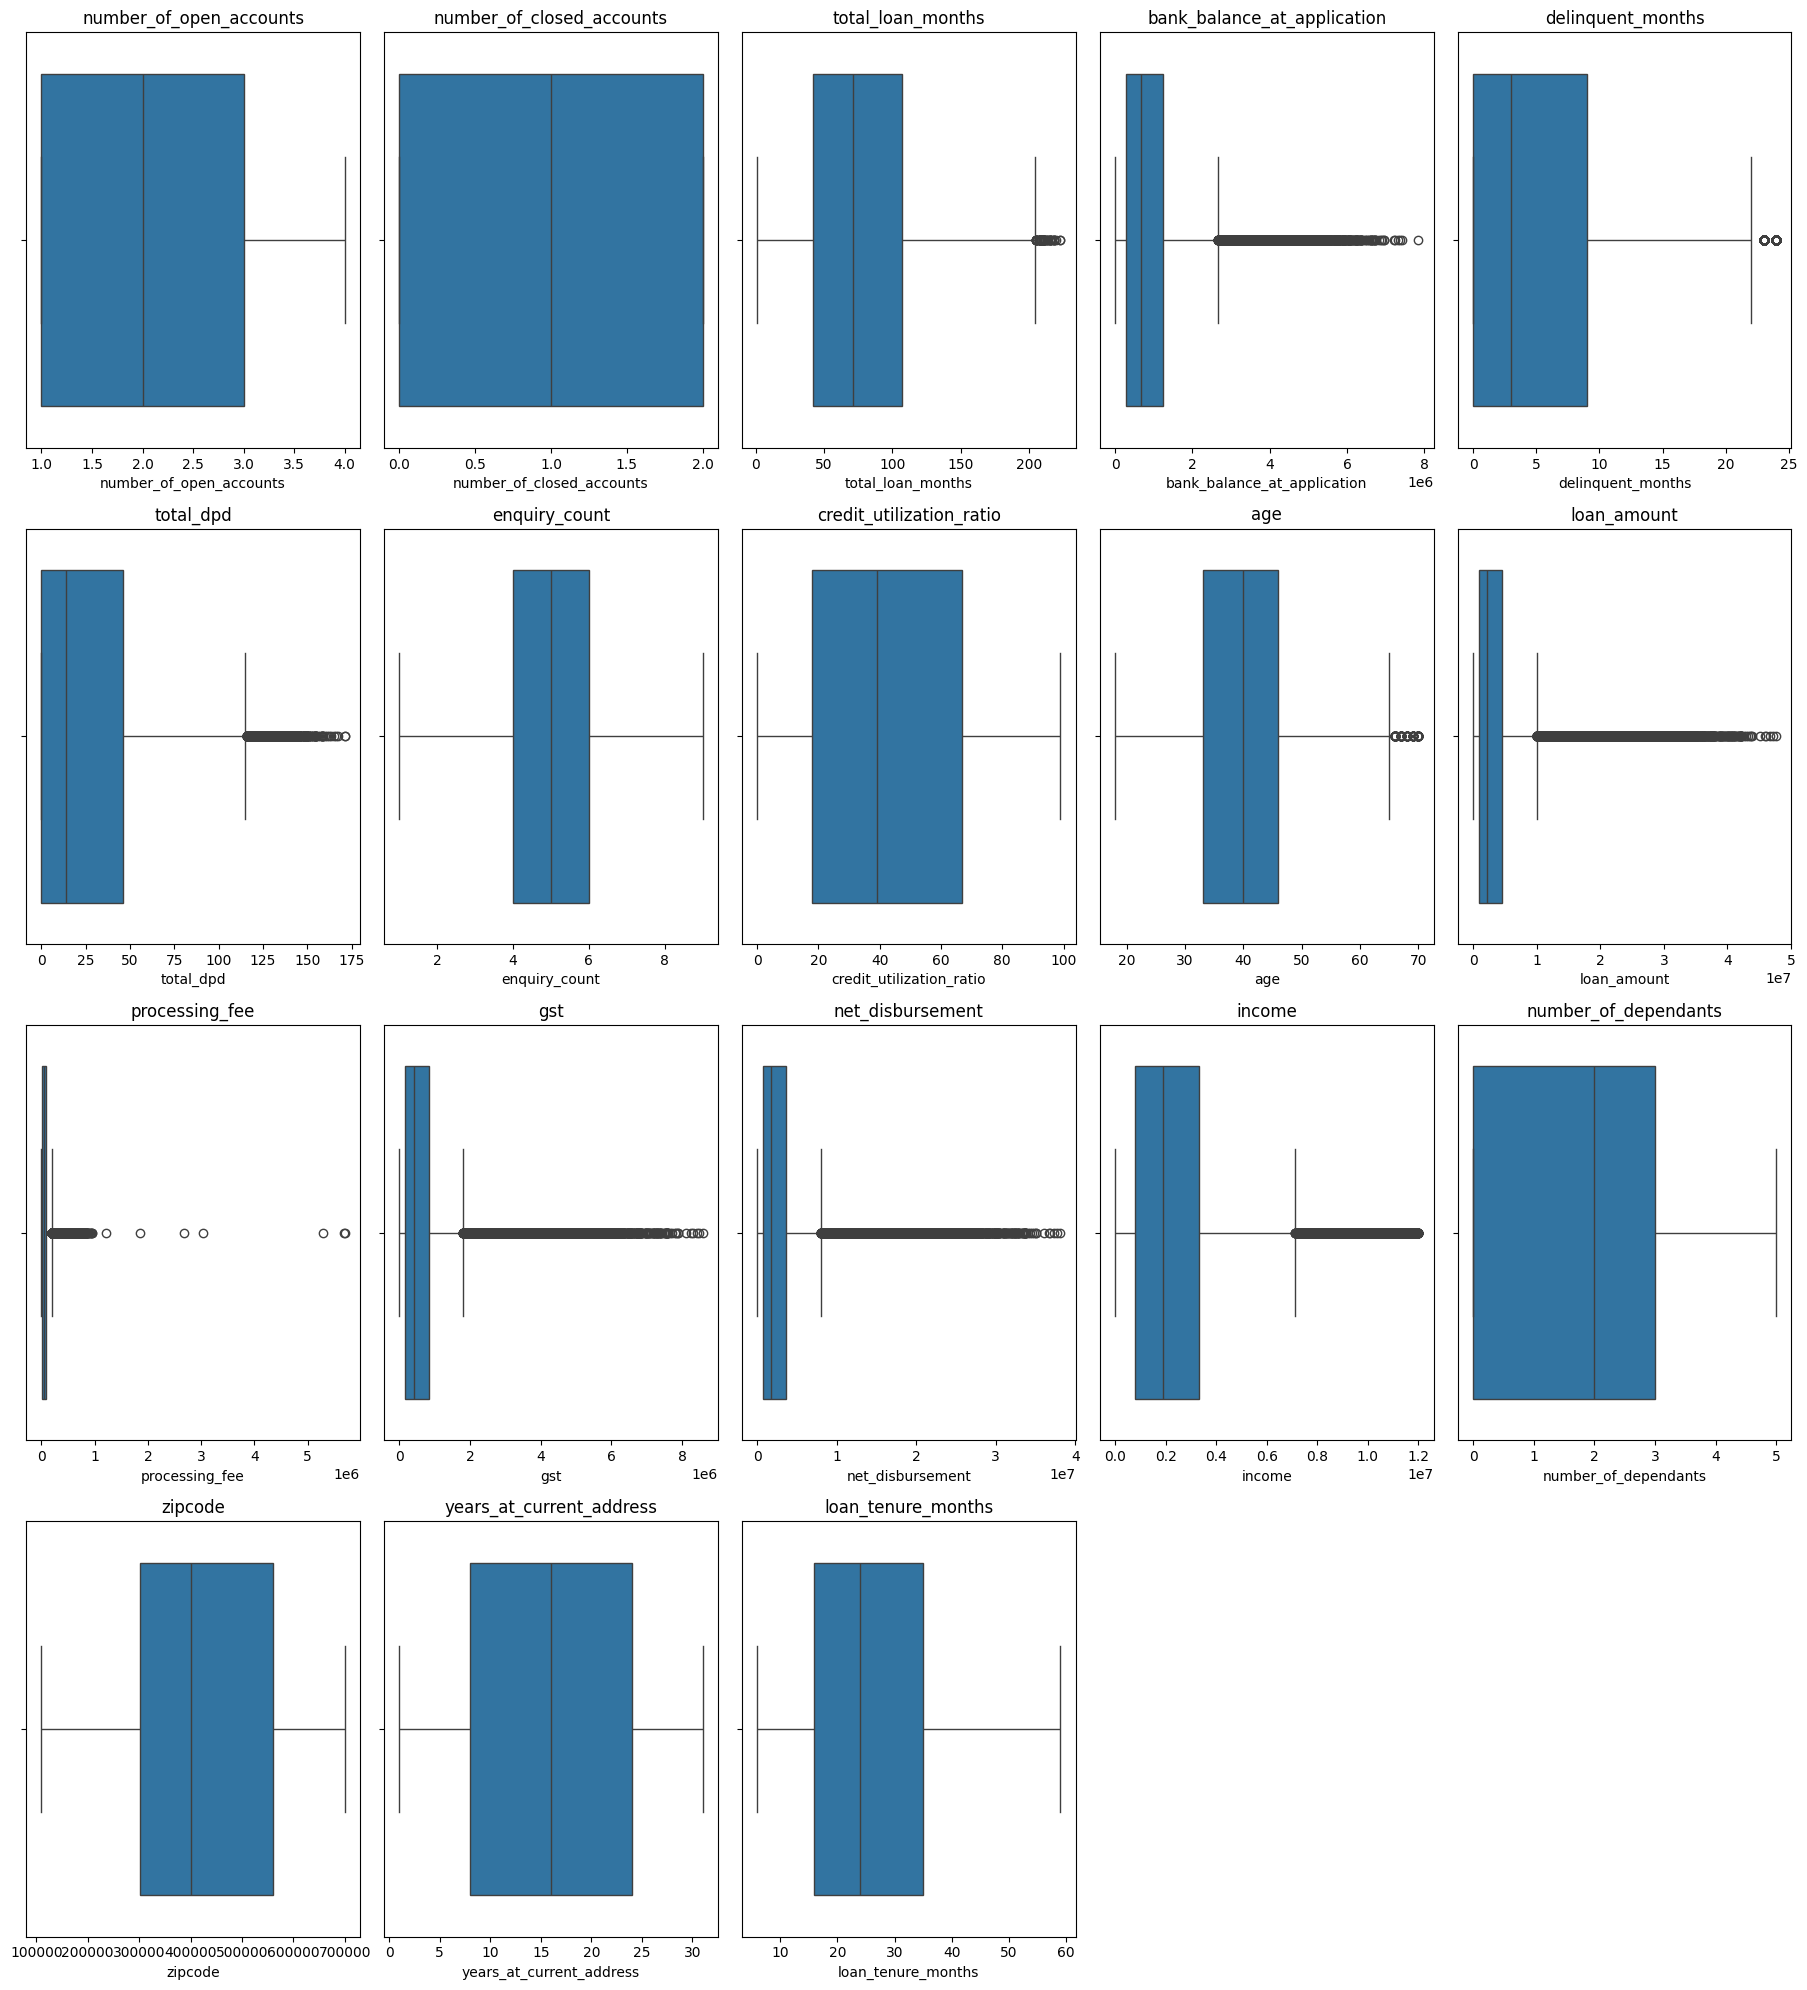

In [253]:
fig, axes = plt.subplots(4,5, figsize=(18, 5 * 4))
axes = axes.flatten()

for ax, col in zip(axes, number_cols):
    sns.boxplot(x=df_train[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(number_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

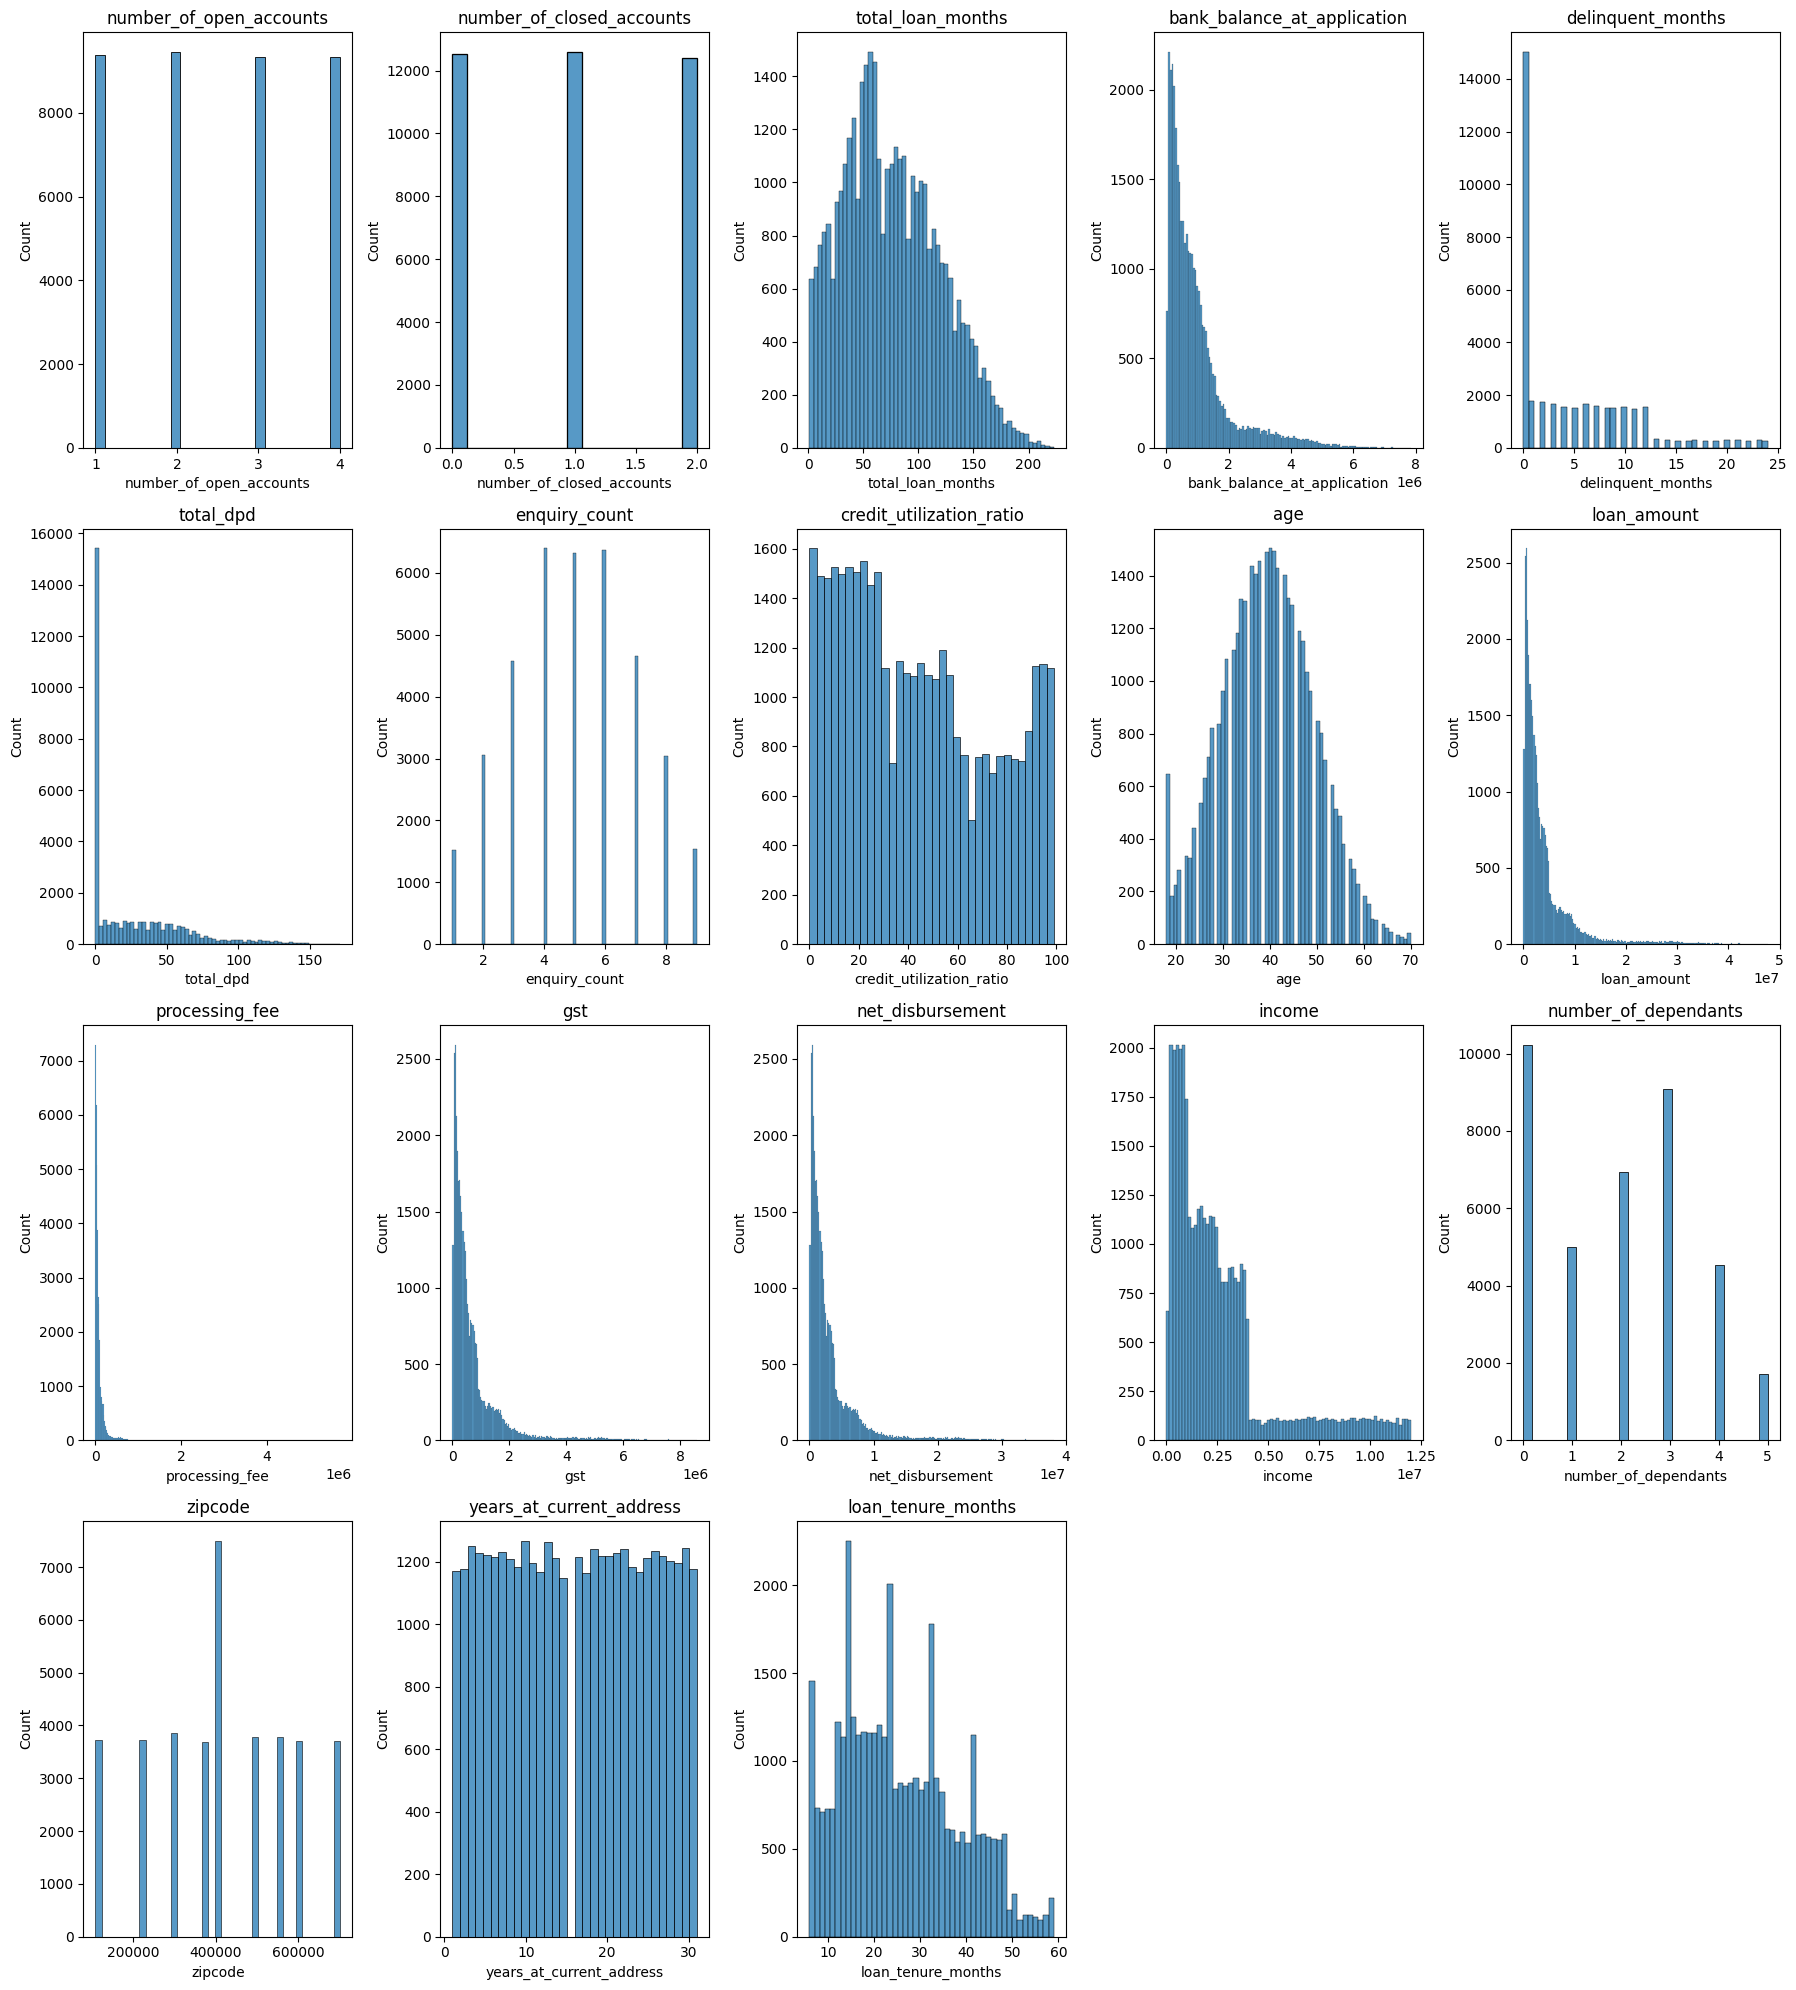

In [254]:
fig, axes = plt.subplots(4,5, figsize=(18, 5 * 4))
axes = axes.flatten()

for ax, col in zip(axes, number_cols):
    sns.histplot(x=df_train[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(number_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [255]:
df_train=df_train[(df_train.processing_fee/df_train.loan_amount) < 0.03].copy()
df_train[(df_train.processing_fee/df_train.loan_amount) > 0.03][['processing_fee','loan_amount']]

,processing_fee,loan_amount


In [256]:
df_test=df_test[(df_test.processing_fee/df_test.loan_amount) < 0.03].copy()


In [257]:
df_train['loan_purpose']=df_train['loan_purpose'].replace('Personaal','Personal')
df_test['loan_purpose']=df_test['loan_purpose'].replace('Personaal','Personal')
df_train['loan_purpose'].unique()

<ArrowStringArray>
['Home', 'Auto', 'Personal', 'Education']
Length: 4, dtype: str

<h1 style="text-align:center;">Exploratory Data Analysis (EDA)</h1>

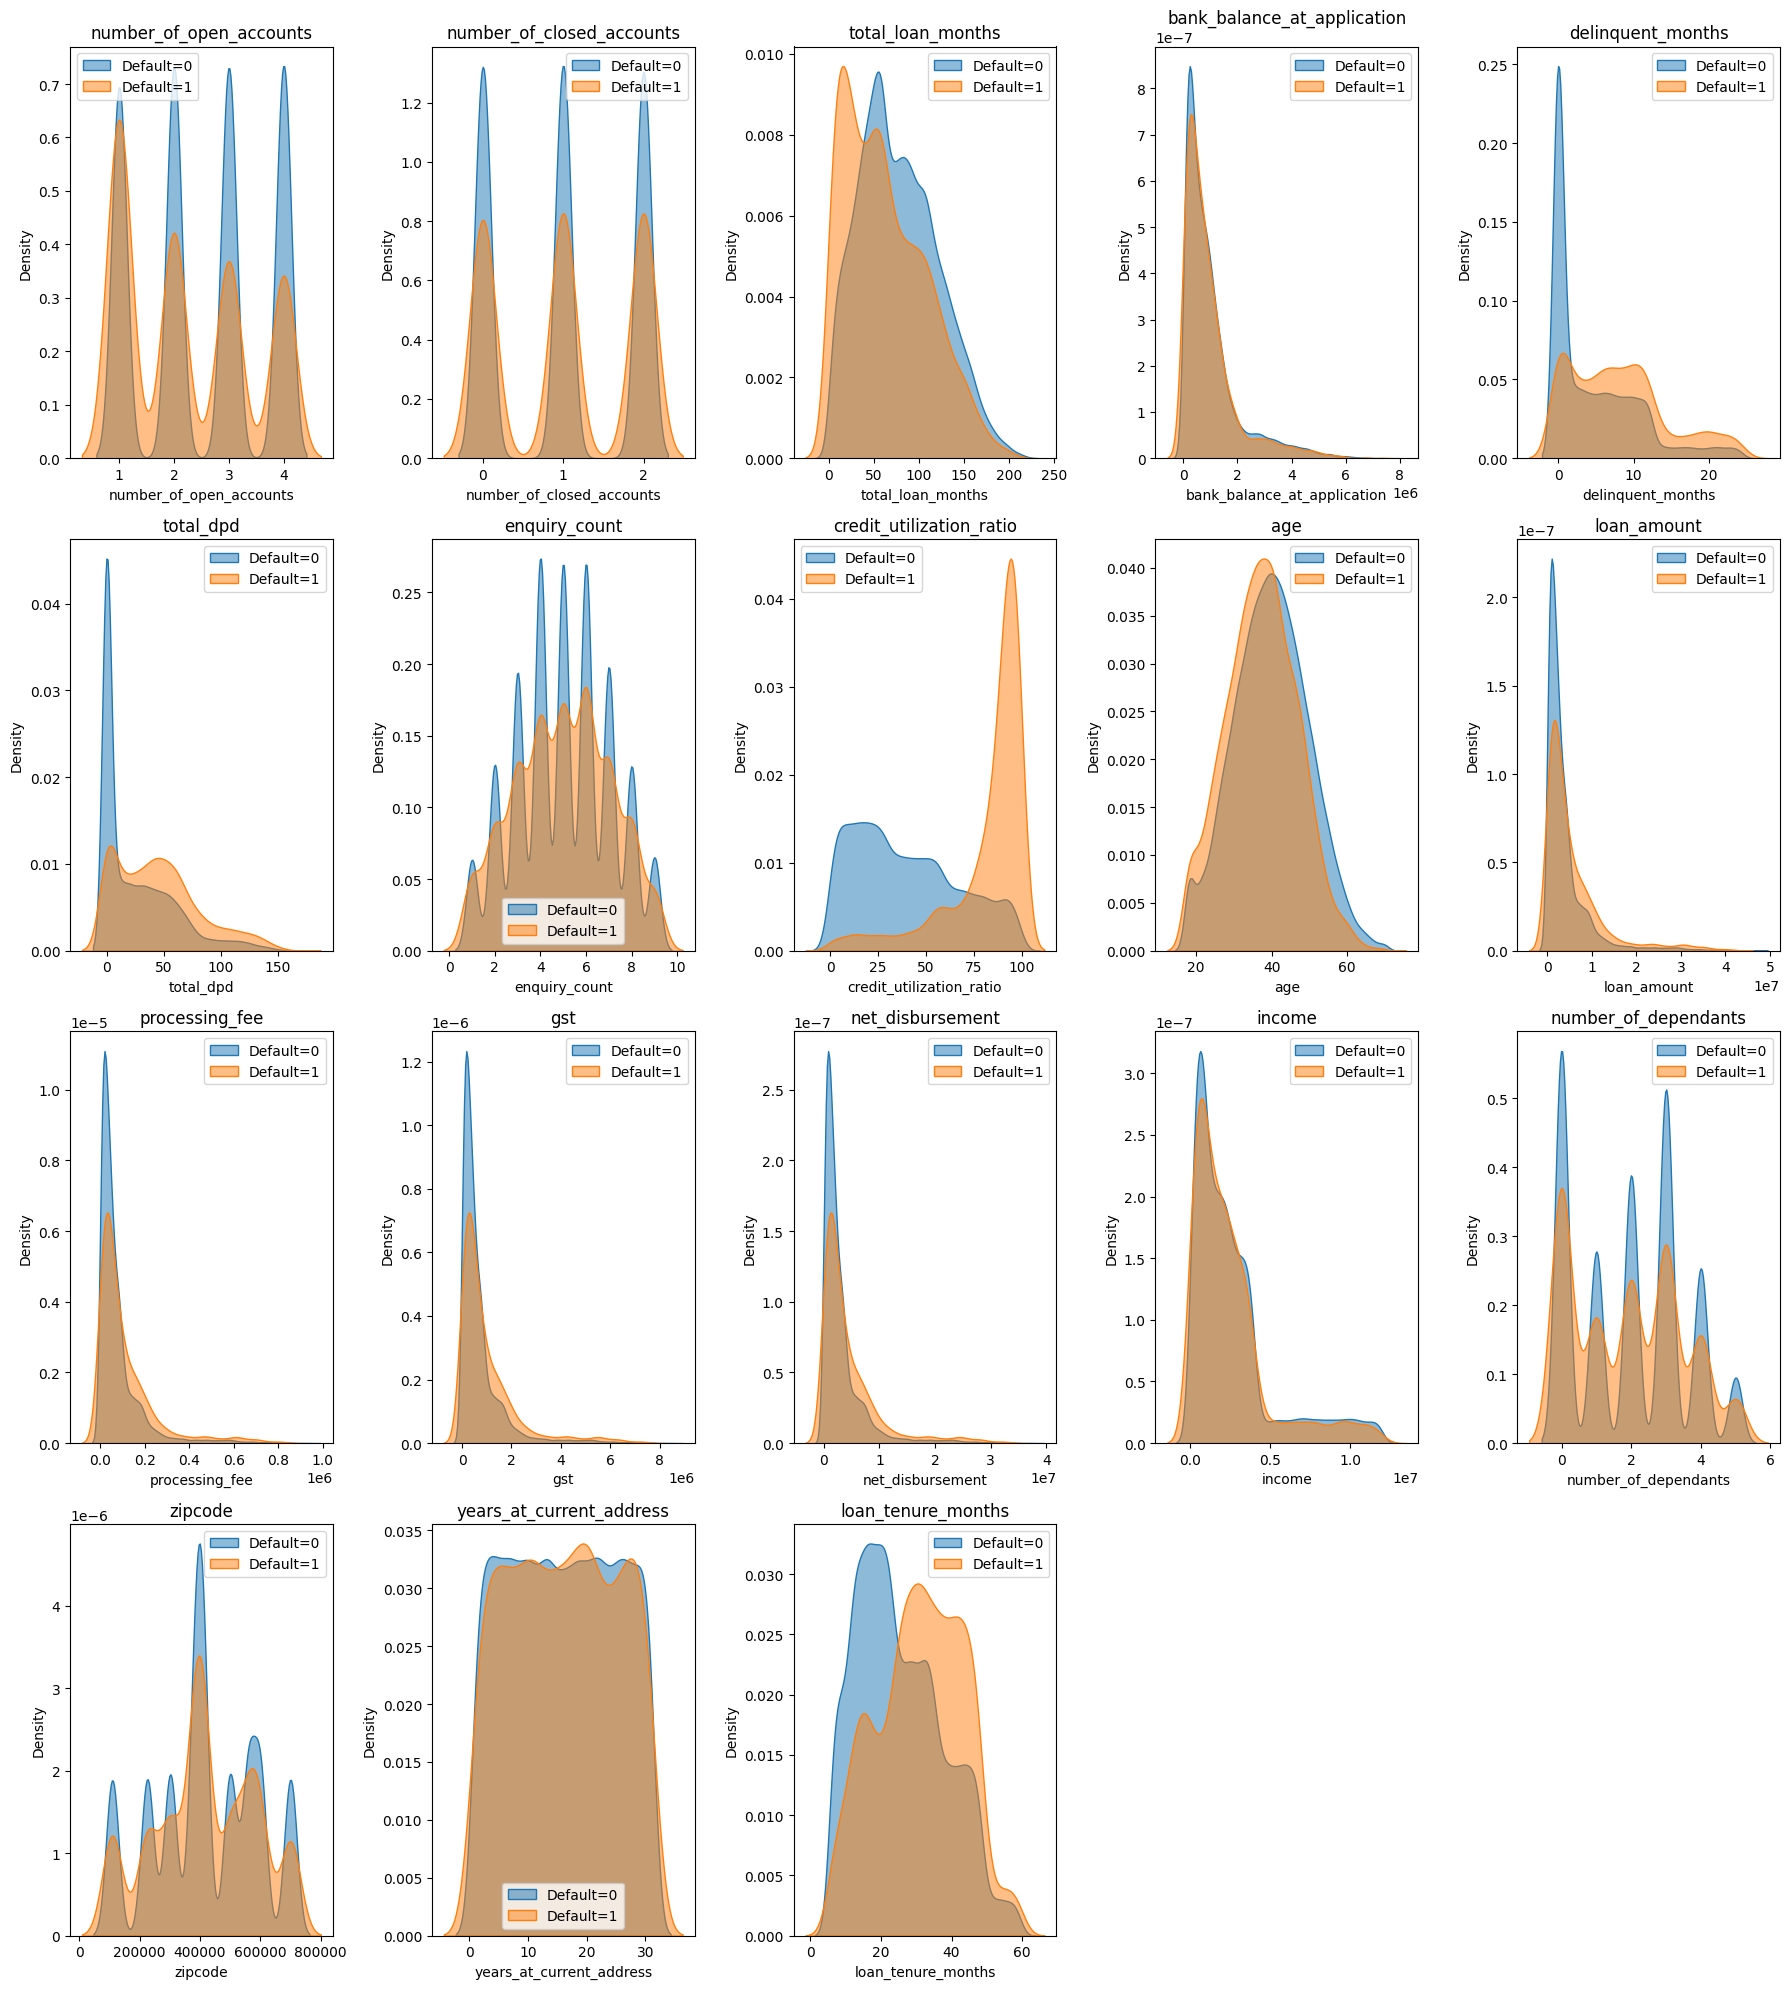

In [258]:
fig, axes = plt.subplots(4,5, figsize=(18, 5 * 4))
axes = axes.flatten()

for ax, col in zip(axes, number_cols):
    sns.kdeplot(x=df_train[df_train['default']==0][col], ax=ax,fill=True, label='Default=0', alpha=0.5)
    sns.kdeplot(x=df_train[df_train['default']==1][col], ax=ax,fill=True, label='Default=1', alpha=0.5)
    ax.set_title(col)
    ax.legend()

for ax in axes[len(number_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [259]:
df_train['loan_to_income_ratio'] = round(df_train['loan_amount'] / df_train['income'], 2)
df_test['loan_to_income_ratio'] = round(df_test['loan_amount'] / df_test['income'], 2)


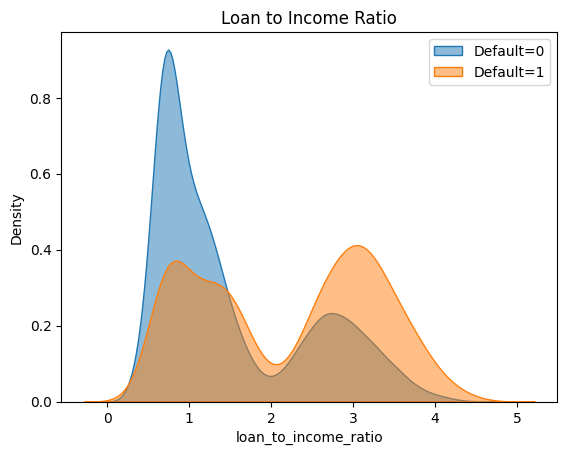

In [260]:

sns.kdeplot(x=df_train[df_train['default']==0]['loan_to_income_ratio'],fill=True, label='Default=0', alpha=0.5)
sns.kdeplot(x=df_train[df_train['default']==1]['loan_to_income_ratio'],fill=True, label='Default=1', alpha=0.5)
plt.title('Loan to Income Ratio')
plt.legend()


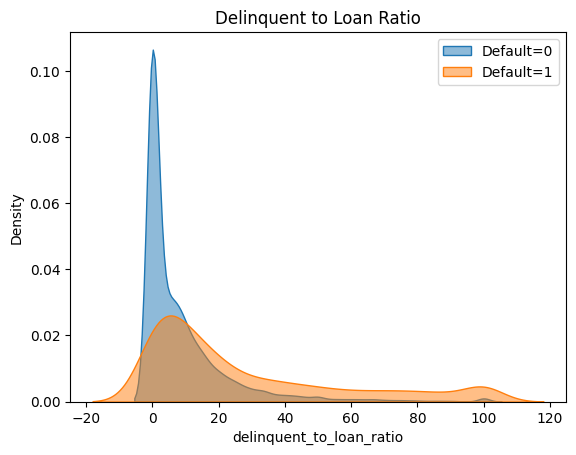

In [261]:
df_train['delinquent_to_loan_ratio'] = round((df_train['delinquent_months']*100) / df_train['total_loan_months'], 2)
df_test['delinquent_to_loan_ratio'] = round((df_test['delinquent_months']*100) / df_test['total_loan_months'], 2)
sns.kdeplot(x=df_train[df_train['default']==0]['delinquent_to_loan_ratio'],fill=True, label='Default=0', alpha=0.5)
sns.kdeplot(x=df_train[df_train['default']==1]['delinquent_to_loan_ratio'],fill=True, label='Default=1', alpha=0.5)
plt.title('Delinquent to Loan Ratio')
plt.legend()

In [262]:
df_train[['delinquent_to_loan_ratio']].describe()

,delinquent_to_loan_ratio
count,37487.000000
mean,10.394472
std,17.268554
min,0.000000
25%,0.000000
50%,3.800000
75%,13.110000
max,100.000000


In [263]:
df_train[['total_dpd','delinquent_months']]

,total_dpd,delinquent_months
27434,33,6
13400,17,4
883,78,14
7303,0,0
45124,28,6
...,...,...
11284,126,23
44732,0,0
38158,0,0
860,24,5


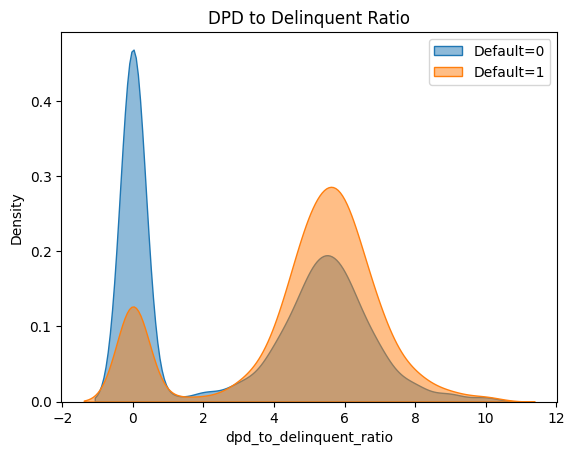

In [264]:

df_train['dpd_to_delinquent_ratio'] = np.where(df_train['delinquent_months'] != 0, round(df_train['total_dpd']/ df_train['delinquent_months'], 2), 0)
df_test['dpd_to_delinquent_ratio'] = np.where(df_test['delinquent_months'] != 0, round(df_test['total_dpd']/ df_test['delinquent_months'], 2), 0)
sns.kdeplot(x=df_train[df_train['default']==0]['dpd_to_delinquent_ratio'],fill=True, label='Default=0', alpha=0.5)
sns.kdeplot(x=df_train[df_train['default']==1]['dpd_to_delinquent_ratio'],fill=True, label='Default=1', alpha=0.5)
plt.title('DPD to Delinquent Ratio')
plt.legend()
plt.show()


In [265]:
df_train.columns

Index(['cust_id', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'age', 'gender', 'marital_status',
       'employment_status', 'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default',
       'loan_to_income_ratio', 'delinquent_to_loan_ratio',
       'dpd_to_delinquent_ratio'],
      dtype='str')

FEATURE SELECTION

In [266]:
df_train=df_train.drop(columns=['number_of_open_accounts','marital_status', 'number_of_closed_accounts','cust_id','loan_id','delinquent_months','total_dpd','total_loan_months','loan_amount','income','disbursal_date','installment_start_dt','sanction_amount'])
features=df_train.columns
df_test=df_test[features]
df_train.shape,df_test.shape


((37487, 23), (12498, 23))

In [267]:
x_train=df_train.drop(columns=['default','zipcode'])
y_train=df_train['default']
scaler=MinMaxScaler()
number_df=x_train.select_dtypes(include=['float64', 'int64'])
cols_to_scale=number_df.columns
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
cols_to_scale


Index(['enquiry_count', 'credit_utilization_ratio', 'age',
       'number_of_dependants', 'years_at_current_address', 'processing_fee',
       'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'loan_to_income_ratio', 'delinquent_to_loan_ratio',
       'dpd_to_delinquent_ratio'],
      dtype='str')

In [268]:
x_test=df_test.drop(columns=['default','zipcode'])
y_test=df_test[['default']]
x_test[cols_to_scale] = scaler.fit_transform(x_test[cols_to_scale])
x_test.head()

,enquiry_count,credit_utilization_ratio,age,gender,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,...,loan_type,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income_ratio,delinquent_to_loan_ratio,dpd_to_delinquent_ratio
33553,0.500,0.121212,0.346154,F,Self-Employed,0.6,Owned,0.466667,Hyderabad,Telangana,...,Secured,0.097523,0.097523,0.097523,0.528302,0.303452,0.256828,0.256410,0.0429,0.900
9427,1.000,0.858586,0.288462,F,Salaried,0.0,Owned,0.466667,Jaipur,Rajasthan,...,Secured,0.183699,0.183699,0.183699,0.622642,0.265925,0.114677,0.685315,0.0000,0.000
199,0.375,0.727273,0.192308,M,Self-Employed,0.0,Owned,0.600000,Delhi,Delhi,...,Secured,0.066432,0.066432,0.066432,0.622642,0.101394,0.045241,0.631702,0.0000,0.000
12447,0.375,0.909091,0.192308,M,Salaried,0.6,Rented,0.100000,Delhi,Delhi,...,Secured,0.026045,0.026045,0.026045,0.188679,0.118056,0.047337,0.186480,0.0000,0.000
39489,1.000,0.535354,0.653846,M,Self-Employed,0.4,Owned,0.833333,Pune,Maharashtra,...,Secured,0.043171,0.043171,0.043171,0.377358,0.293165,0.069255,0.167832,0.1316,0.525


In [269]:
y_train.head()

27434    0
13400    0
883      0
7303     0
45124    0
Name: default, dtype: int64

In [270]:
def calculate_vif(x):
    vif_data = pd.DataFrame()
    vif_data["feature"] = x.columns
    vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
    
    return vif_data


In [271]:
number_df=x_train.select_dtypes(include=['float64', 'int64'])

calculate_vif(x_train[number_df.columns])

c:\Users\vaisa\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,enquiry_count,4.197149
1,credit_utilization_ratio,2.869194
2,age,5.497847
3,number_of_dependants,2.717878
4,years_at_current_address,3.325452
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.054845
9,principal_outstanding,16.031797


In [272]:
x_test=x_test.drop(columns=['gst','processing_fee','net_disbursement','principal_outstanding','bank_balance_at_application'])
x_train=x_train.drop(columns=['gst','processing_fee','net_disbursement','principal_outstanding','bank_balance_at_application'])


In [273]:
x_train[['dpd_to_delinquent_ratio','delinquent_to_loan_ratio']].describe()

,dpd_to_delinquent_ratio,delinquent_to_loan_ratio
count,37487.000000,37487.000000
mean,0.329461,0.103945
std,0.290335,0.172686
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.433000,0.038000
75%,0.575000,0.131100
max,1.000000,1.000000


In [274]:
temp=pd.concat([x_train,y_train],axis=1)
temp.groupby('loan_purpose')['default'].agg(['count','sum'])


,count,sum
loan_purpose,,
Auto,7437,314
Education,5626,546
Home,11271,1744
Personal,13153,585


In [275]:

def calculate_woe_iv(data,feature,target):
    grouped=data.groupby(feature)[target].agg(['count','sum'])
    grouped=grouped.rename(columns={'count':'total','sum':'good'})
    grouped['bad']=grouped['total']-grouped['good']
    total_good=grouped['good'].sum()
    total_bad=grouped['bad'].sum()
    grouped['good_pct']=grouped['good']/total_good
    grouped['bad_pct']=grouped['bad']/total_bad
    grouped['good_pct'] = grouped['good_pct'].replace(0, 1e-10)
    grouped['bad_pct'] = grouped['bad_pct'].replace(0, 1e-10)
    grouped['woe']=np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv']=grouped['woe']*(grouped['good_pct']-grouped['bad_pct'])
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    total_iv=grouped['iv'].sum()
    return grouped,total_iv


In [276]:
iv_values={}
from pandas.api.types import is_string_dtype
for feature in x_train.columns:
    
    if is_string_dtype(x_train[feature]):
       _,iv= calculate_woe_iv(temp,feature,'default')
    else:
       temp[feature] = pd.cut(temp[feature], bins=10)
       _,iv=calculate_woe_iv(temp,feature,'default')
    iv_values[feature]=iv
    


     

In [277]:
iv_values

{'enquiry_count': np.float64(0.005484982638303533),
 'credit_utilization_ratio': np.float64(2.4228228499400095),
 'age': np.float64(0.07592687127752061),
 'gender': np.float64(0.000482276463421216),
 'employment_status': np.float64(0.002447818101774487),
 'number_of_dependants': np.float64(0.00364589452118596),
 'residence_type': np.float64(0.2594019617563985),
 'years_at_current_address': np.float64(0.001042536380353028),
 'city': np.float64(0.000817870465334103),
 'state': np.float64(0.0007881984519711978),
 'loan_purpose': np.float64(0.39377543144164784),
 'loan_type': np.float64(0.17304705897793143),
 'loan_tenure_months': np.float64(0.23450610202970526),
 'loan_to_income_ratio': np.float64(0.4915664145044282),
 'delinquent_to_loan_ratio': np.float64(0.678322540101926),
 'dpd_to_delinquent_ratio': np.float64(0.42123646562822287)}

In [278]:
iv_df=pd.DataFrame(list(iv_values.items()),columns=['feature','iv'])
iv_df=iv_df.sort_values(by='iv',ascending=True)

iv_df

,feature,iv
3,gender,0.000482
9,state,0.000788
8,city,0.000818
7,years_at_current_address,0.001043
4,employment_status,0.002448
5,number_of_dependants,0.003646
0,enquiry_count,0.005485
2,age,0.075927
11,loan_type,0.173047
12,loan_tenure_months,0.234506


In [279]:
selected_features=[feature for feature,iv in iv_values.items() if iv>0.02]
selected_features


['credit_utilization_ratio',
 'age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'loan_to_income_ratio',
 'delinquent_to_loan_ratio',
 'dpd_to_delinquent_ratio']

FEATURE ENCODING

In [280]:
x_train_reduced=x_train[selected_features]
x_test_reduced=x_test[selected_features]
x_train_reduced.head()

,credit_utilization_ratio,age,residence_type,loan_purpose,loan_type,loan_tenure_months,loan_to_income_ratio,delinquent_to_loan_ratio,dpd_to_delinquent_ratio
27434,0.595960,0.519231,Owned,Home,Secured,0.339623,0.608899,0.0667,0.550
13400,0.929293,0.211538,Owned,Auto,Secured,0.509434,0.182670,0.0336,0.425
883,0.838384,0.615385,Mortgage,Personal,Unsecured,0.245283,0.084309,0.1687,0.557
7303,0.343434,0.480769,Owned,Auto,Secured,0.283019,0.187354,0.0000,0.000
45124,0.191919,0.250000,Owned,Education,Secured,0.735849,0.360656,0.0968,0.467


In [281]:
x_train_reduced=pd.get_dummies(x_train_reduced,drop_first=True,dtype=int)
x_test_reduced=pd.get_dummies(x_test_reduced,drop_first=True,dtype=int)
x_train_reduced.head()

,credit_utilization_ratio,age,loan_tenure_months,loan_to_income_ratio,delinquent_to_loan_ratio,dpd_to_delinquent_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
27434,0.595960,0.519231,0.339623,0.608899,0.0667,0.550,1,0,0,1,0,0
13400,0.929293,0.211538,0.509434,0.182670,0.0336,0.425,1,0,0,0,0,0
883,0.838384,0.615385,0.245283,0.084309,0.1687,0.557,0,0,0,0,1,1
7303,0.343434,0.480769,0.283019,0.187354,0.0000,0.000,1,0,0,0,0,0
45124,0.191919,0.250000,0.735849,0.360656,0.0968,0.467,1,0,1,0,0,0


ATTEMPT:
Handle Class Imbalance By Oversampling Using Smote

In [282]:
from imblearn.combine import SMOTETomek
smote=SMOTETomek(random_state=3)
x_train_smote,y_train_smote=smote.fit_resample(x_train_reduced,y_train)
model=LogisticRegression()
model.fit(x_train_smote,y_train_smote)
ypred=model.predict(x_test_reduced)
print(classification_report(y_test,ypred))
y_train_smote.value_counts()

              precision    recall  f1-score   support

       False       0.99      0.93      0.96     11390
        True       0.56      0.94      0.70      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



default
0    34226
1    34226
Name: count, dtype: int64

In [283]:
import optuna
def objective(trial):
    params={'C':trial.suggest_float('C',1,5),
    'solver':trial.suggest_categorical('solver',['liblinear','lbfgs','saga','sag','newton-cg']),'tol':trial.suggest_float('tol',1e-6,1e-1,log=True),'class_weight':trial.suggest_categorical('class_weight',['balanced',None])}
    model=LogisticRegression(**params,max_iter=10000)
    scores=cross_val_score(model,x_train_smote,y_train_smote,cv=3,scoring='recall',n_jobs=-1)
    accuracy=np.mean(scores)
    return accuracy

study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)



[I 2026-07-13 19:05:42,860] A new study created in memory with name: no-name-5157d968-0b0a-4591-a16e-db5eb6f013e2
[I 2026-07-13 19:05:43,056] Trial 0 finished with value: 0.9647636657837323 and parameters: {'C': 1.763612708472182, 'solver': 'liblinear', 'tol': 0.09931006376788223, 'class_weight': None}. Best is trial 0 with value: 0.9647636657837323.
[I 2026-07-13 19:05:43,393] Trial 1 finished with value: 0.9582189405270505 and parameters: {'C': 3.982216211252611, 'solver': 'saga', 'tol': 1.3905153708787864e-06, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9647636657837323.
[I 2026-07-13 19:05:43,562] Trial 2 finished with value: 0.958072869831077 and parameters: {'C': 2.4699326346049, 'solver': 'saga', 'tol': 0.006886088196593556, 'class_weight': None}. Best is trial 0 with value: 0.9647636657837323.
[I 2026-07-13 19:05:43,708] Trial 3 finished with value: 0.9583650317115934 and parameters: {'C': 3.5143557313864235, 'solver': 'lbfgs', 'tol': 8.611147586436964e-06, 'clas

In [284]:
print(f"best parameter:{study.best_params}")
print(f"best trial:{study.best_trial}")
print(f"Recall:{study.best_trial.value}")

best parameter:{'C': 2.1231124164646373, 'solver': 'newton-cg', 'tol': 0.02594131107948315, 'class_weight': None}
best trial:FrozenTrial(number=24, state=<TrialState.COMPLETE: 1>, values=[0.9666043768051198], datetime_start=datetime.datetime(2026, 7, 13, 19, 5, 47, 185057), datetime_complete=datetime.datetime(2026, 7, 13, 19, 5, 47, 316816), params={'C': 2.1231124164646373, 'solver': 'newton-cg', 'tol': 0.02594131107948315, 'class_weight': None}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'C': FloatDistribution(high=5.0, log=False, low=1.0, step=None), 'solver': CategoricalDistribution(choices=('liblinear', 'lbfgs', 'saga', 'sag', 'newton-cg')), 'tol': FloatDistribution(high=0.1, log=True, low=1e-06, step=None), 'class_weight': CategoricalDistribution(choices=('balanced', None))}, trial_id=24, value=None)
Recall:0.9666043768051198


In [300]:
model_final_lr=LogisticRegression(**study.best_params,random_state=3)
model_final_lr.fit(x_train_smote,y_train_smote)
ypred_lr=model_final_lr.predict(x_test_reduced)
print(classification_report(y_test,ypred_lr))

              precision    recall  f1-score   support

       False       1.00      0.86      0.92     11390
        True       0.40      0.96      0.57      1108

    accuracy                           0.87     12498
   macro avg       0.70      0.91      0.75     12498
weighted avg       0.94      0.87      0.89     12498



Background dataset has 68452 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=68452 when initializing the masker.


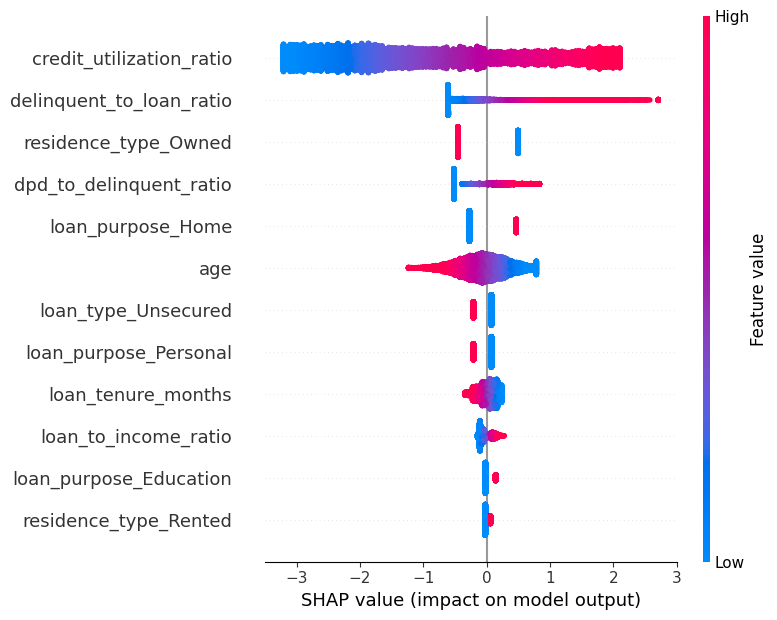

In [286]:
import shap
lr_explainer=shap.LinearExplainer(model_final_lr,x_train_smote)
lr_shap_values=lr_explainer(x_test_reduced)
shap.summary_plot(lr_shap_values,x_test_reduced)

Attempt 2: using xgboost

In [287]:
def objective_xgb(trial):
    params = {
    "n_estimators": trial.suggest_int("n_estimators", 100, 500),

    "max_depth": trial.suggest_int("max_depth", 3, 10),

    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),

    "subsample": trial.suggest_float("subsample", 0.5, 1.0),

    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

    "gamma": trial.suggest_float("gamma", 0, 5),

    "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

    "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),

    "reg_lambda": trial.suggest_float("reg_lambda", 0, 10)
}
    model=XGBClassifier(**params)
    scores=cross_val_score(model,x_train_smote,y_train_smote,cv=3,n_jobs=-1,scoring='recall')
    accuracy=np.mean(scores)
    return accuracy

subject_xgb=optuna.create_study(direction='maximize')
subject_xgb.optimize(objective_xgb,n_trials=10)


[I 2026-07-13 19:05:52,241] A new study created in memory with name: no-name-e3b06acf-d46b-4585-a4f3-516bc93d593e
[I 2026-07-13 19:05:53,888] Trial 0 finished with value: 0.9818561781499158 and parameters: {'n_estimators': 497, 'max_depth': 10, 'learning_rate': 0.23917216268982938, 'subsample': 0.7600735156944602, 'colsample_bytree': 0.8187472069550294, 'gamma': 3.759183906025792, 'min_child_weight': 2, 'reg_alpha': 5.559032619900756, 'reg_lambda': 2.8923368239264846}. Best is trial 0 with value: 0.9818561781499158.
[I 2026-07-13 19:05:54,921] Trial 1 finished with value: 0.983930553624508 and parameters: {'n_estimators': 294, 'max_depth': 5, 'learning_rate': 0.24288388717508458, 'subsample': 0.9983996965667966, 'colsample_bytree': 0.5941282307074476, 'gamma': 2.0041379441431175, 'min_child_weight': 8, 'reg_alpha': 5.872429516978822, 'reg_lambda': 8.335381809257344}. Best is trial 1 with value: 0.983930553624508.
[I 2026-07-13 19:05:56,262] Trial 2 finished with value: 0.98293724984224

In [288]:
print(f"best parameter:{subject_xgb.best_params}")
print(f"best trial:{subject_xgb.best_trial}")
print(f"Recall:{subject_xgb.best_trial.value}")

best parameter:{'n_estimators': 103, 'max_depth': 7, 'learning_rate': 0.1918967228129608, 'subsample': 0.6251442358535731, 'colsample_bytree': 0.7246345446530151, 'gamma': 2.148742496501259, 'min_child_weight': 1, 'reg_alpha': 6.788424294688192, 'reg_lambda': 7.634248435712186}
best trial:FrozenTrial(number=9, state=<TrialState.COMPLETE: 1>, values=[0.9845148543358997], datetime_start=datetime.datetime(2026, 7, 13, 19, 6, 5, 225533), datetime_complete=datetime.datetime(2026, 7, 13, 19, 6, 5, 834782), params={'n_estimators': 103, 'max_depth': 7, 'learning_rate': 0.1918967228129608, 'subsample': 0.6251442358535731, 'colsample_bytree': 0.7246345446530151, 'gamma': 2.148742496501259, 'min_child_weight': 1, 'reg_alpha': 6.788424294688192, 'reg_lambda': 7.634248435712186}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=500, log=False, low=100, step=1), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'learning_rate'

In [289]:
model_final_xgb=XGBClassifier(**subject_xgb.best_params)
model_final_xgb.fit(x_train_smote,y_train_smote)
ypred_xgb=model_final_xgb.predict(x_test_reduced)
print(classification_report(y_test,ypred_xgb))
ypred_xgb

              precision    recall  f1-score   support

       False       0.99      0.96      0.97     11390
        True       0.69      0.89      0.78      1108

    accuracy                           0.96     12498
   macro avg       0.84      0.93      0.88     12498
weighted avg       0.96      0.96      0.96     12498



array([0, 0, 0, ..., 0, 0, 0], shape=(12498,))

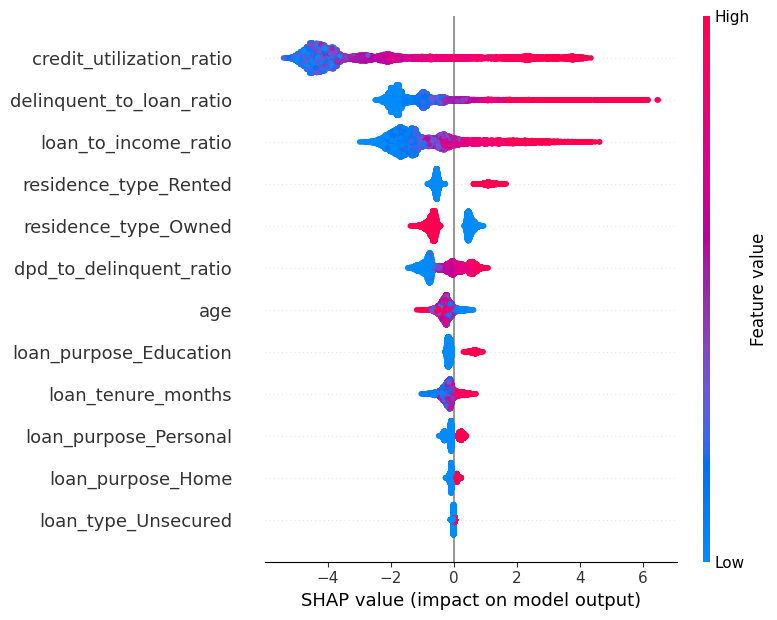

In [291]:
xgb_explainer = shap.TreeExplainer(model_final_xgb, feature_perturbation='tree_path_dependent')
xgb_shap_values = xgb_explainer(x_test_reduced)
shap.summary_plot(xgb_shap_values, x_test_reduced)

In [292]:
from sklearn.metrics import roc_curve
probabilities=model_final_lr.predict_proba(x_test_reduced)[:,1]
fpr,tpr,threshold=roc_curve(y_test,probabilities)
y_test = y_test.squeeze()
probabilities.shape




(12498,)

In [293]:
ks_stat_df=pd.DataFrame(data={'default_truth':y_test,'default_probability':probabilities},dtype=float)
ks_stat_df.shape

(12498, 2)

In [294]:
ks_stat_df['decile']=pd.qcut(ks_stat_df['default_probability'],10,labels=False,duplicates='drop')
ks_stat_df.value_counts()

default_truth  default_probability  decile
0.0            0.044301             2         1
               0.575839             8         1
               0.445108             7         1
               0.749756             9         1
               0.139610             5         1
                                             ..
               0.035115             2         1
               0.030816             1         1
               0.036181             2         1
               0.010298             0         1
               0.557025             8         1
Name: count, Length: 12498, dtype: int64

In [295]:
stat_df_grouped=ks_stat_df.groupby('decile').apply(lambda x:pd.Series({'max_probability':x['default_probability'].max(),'min_probability':x['default_probability'].min(),'events':x['default_truth'].sum(),'non-events':x['default_truth'].count()-x['default_truth'].sum()})).round(2)
stat_df_grouped.reset_index(inplace=True)
stat_df_grouped.sort_values(ascending=False,by='decile',inplace=True)

In [296]:
stat_df_grouped['event_rate']=stat_df_grouped['events']*100/(stat_df_grouped['events']+stat_df_grouped['non-events'])
stat_df_grouped['non-event_rate']=stat_df_grouped['non-events']*100/(stat_df_grouped['events']+stat_df_grouped['non-events'])
stat_df_grouped["cumilative_events"]=stat_df_grouped['events'].cumsum()
stat_df_grouped["non_cumilative_events"]=stat_df_grouped['non-events'].cumsum()
stat_df_grouped['cumilative_event_rate']=stat_df_grouped['cumilative_events']*100/(stat_df_grouped['events'].sum())
stat_df_grouped['non_cumilative_event_rate']=stat_df_grouped['non_cumilative_events']*100/(stat_df_grouped['events'].sum())
stat_df_grouped['ks']=abs(stat_df_grouped['cumilative_event_rate']-stat_df_grouped['non_cumilative_event_rate'])
stat_df_grouped.head()

,decile,max_probability,min_probability,events,non-events,event_rate,non-event_rate,cumilative_events,non_cumilative_events,cumilative_event_rate,non_cumilative_event_rate,ks
9,9,0.99,0.73,853.0,397.0,68.240000,31.760000,853.0,397.0,76.985560,35.830325,41.155235
8,8,0.73,0.52,206.0,1044.0,16.480000,83.520000,1059.0,1441.0,95.577617,130.054152,34.476534
7,7,0.52,0.34,32.0,1218.0,2.560000,97.440000,1091.0,2659.0,98.465704,239.981949,141.516245
6,6,0.34,0.22,11.0,1238.0,0.880705,99.119295,1102.0,3897.0,99.458484,351.714801,252.256318
5,5,0.22,0.14,5.0,1245.0,0.400000,99.600000,1107.0,5142.0,99.909747,464.079422,364.169675


In [297]:
from joblib import dump
model_data={'model':model_final_xgb,'features':x_train_reduced.columns,'scaler':scaler,'cols_to_scale':cols_to_scale}

dump(model_data,"C:/Users/vaisa/Downloads/project_2/Credit-Risk-Modelling/model pickle/model.joblib")

['C:/Users/vaisa/Downloads/project_2/Credit-Risk-Modelling/model pickle/model.joblib']